# Does the training opponent matter? Q-learning vs. Random vs. Minimax

Tic-Tac-Toe is a solved game: with perfect play by both sides, every game is
a draw. That gives a clean, provable yardstick for a learned policy — the
**minimax agent** (see [`minimax_agent.py`](../src/tictactoe/agents/minimax_agent.py))
never loses, so *any* loss a Q-learning agent suffers against it is a real,
attributable mistake.

This notebook trains two tabular Q-learning agents with the **exact same
algorithm, hyperparameters, and episode budget** — the only thing that
differs is who they train against:

- **Agent R** trains against a uniformly random opponent.
- **Agent M** trains against the minimax-optimal opponent.

Both are then benchmarked against minimax. The question: does training
against an easy opponent produce a measurably worse policy than training
against a perfect one — and if so, why?

In [1]:
import random
import time

import matplotlib.pyplot as plt
import pandas as pd

from tictactoe.agents import MinimaxAgent, QLearningAgent, RandomAgent
from tictactoe.evaluation import evaluate
from tictactoe.training import train

pd.set_option("display.precision", 3)

## Training protocol

Both agents are trained for 20,000 episodes total, in 40 checkpoints of 500
episodes each. The exploration rate `epsilon` is annealed from 0.3 down to
0.05 across checkpoints (never fully to 0 — see the note in
[`training.py`](../src/tictactoe/training.py) on why that starves rarely-visited
branches). `alternate_sides=True` (the `train()` default) means the learner
plays X on even episodes and O on odd ones against the fixed opponent, so it
practices *both* seats rather than only ever moving first.

After each checkpoint, we freeze the policy (`epsilon=0`, greedy) and play it
against `MinimaxAgent` — as both X and O — to track the loss rate over the
course of training.

In [2]:
def train_with_checkpoints(opponent, total_episodes=20000, n_checkpoints=40, eval_games=200, seed=0):
    random.seed(seed)
    checkpoint_episodes = total_episodes // n_checkpoints
    agent = QLearningAgent(alpha=0.1, gamma=0.95)
    history = []
    for i in range(n_checkpoints):
        progress = i / (n_checkpoints - 1)
        eps = 0.3 + (0.05 - 0.3) * progress
        train(checkpoint_episodes, opponent=opponent, epsilon=eps, agent=agent)

        agent.epsilon = 0.0
        as_x = evaluate(agent, MinimaxAgent(), n_games=eval_games)
        as_o = evaluate(MinimaxAgent(), agent, n_games=eval_games)
        history.append({
            "episodes": (i + 1) * checkpoint_episodes,
            "loss_rate_as_x": as_x["o_wins"],
            "loss_rate_as_o": as_o["x_wins"],
        })
    return agent, pd.DataFrame(history)


t0 = time.time()
agent_vs_random, history_vs_random = train_with_checkpoints(RandomAgent())
print(f"Trained vs Random in {time.time() - t0:.1f}s ({len(agent_vs_random.q)} Q-table entries)")

t0 = time.time()
agent_vs_minimax, history_vs_minimax = train_with_checkpoints(MinimaxAgent())
print(f"Trained vs Minimax in {time.time() - t0:.1f}s ({len(agent_vs_minimax.q)} Q-table entries)")

Trained vs Random in 12.0s (1818 Q-table entries)


Trained vs Minimax in 15.2s (809 Q-table entries)


## Learning curves: loss rate against the minimax oracle

Since minimax never loses, the loss rate against it is exactly the RL
agent's error rate against perfect play — a ground-truth measure of policy
quality, not just "did it win more games."

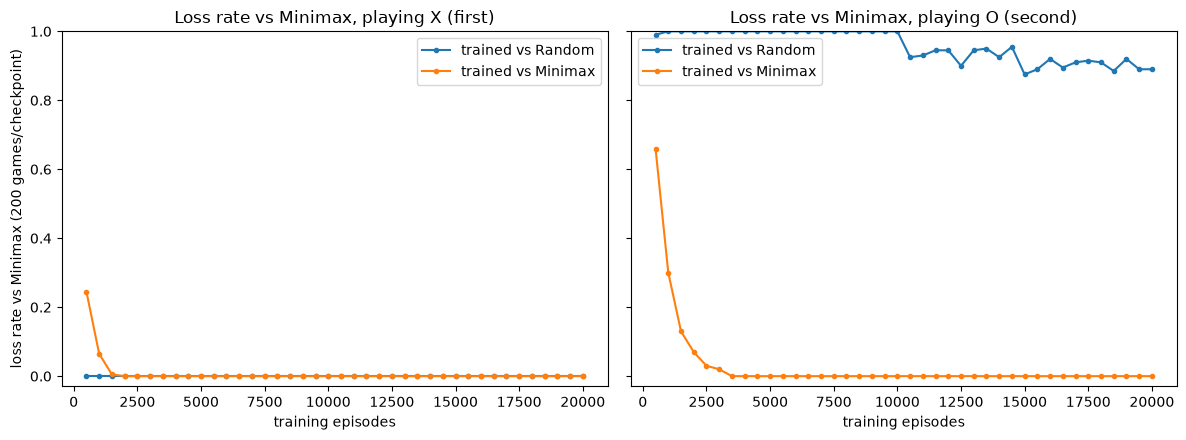

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, col, title in (
    (axes[0], "loss_rate_as_x", "Loss rate vs Minimax, playing X (first)"),
    (axes[1], "loss_rate_as_o", "Loss rate vs Minimax, playing O (second)"),
):
    ax.plot(history_vs_random["episodes"], history_vs_random[col], marker=".", label="trained vs Random")
    ax.plot(history_vs_minimax["episodes"], history_vs_minimax[col], marker=".", label="trained vs Minimax")
    ax.set_title(title)
    ax.set_xlabel("training episodes")
    ax.set_ylim(-0.03, 1.0)
    ax.legend()

axes[0].set_ylabel("loss rate vs Minimax (200 games/checkpoint)")
plt.tight_layout()
plt.show()

Playing first (X), both agents converge to a perfect, never-losing policy —
unsurprising, since going first in Tic-Tac-Toe is the easier seat and even a
fairly shallow policy can force a draw.

Playing second (O) is where the two curricula diverge. The agent trained
against Minimax converges to 0% losses on both seats, matching the
self-play agent from the first phase of this project. The agent trained
against Random does not reliably get there within the same budget.

## Why training against Random doesn't teach good defense

A random opponent essentially never builds a *fork* (two simultaneous
winning threats) — that takes deliberate, coordinated play. So across 10,000
episodes played as O, the agent trained against Random almost never
encounters the specific losing pattern "opponent completes a fork," which is
exactly the situation that punishes weak defense. Its Q-values for those
branches stay close to their untrained default and it has no learned
response when a stronger opponent (Minimax) sets one up.

The agent trained against Minimax faces exactly that pressure on *every*
episode, so it is forced to learn a fully robust defense on both seats — at
the cost of never winning a single training game (the best any agent can do
against Minimax is draw).

## Final evaluation (larger sample)

In [4]:
def summarize(agent, name, n_games=1000):
    agent.epsilon = 0.0
    rows = []
    for opp_name, opp in (("Random", RandomAgent()), ("Minimax", MinimaxAgent())):
        as_x = evaluate(agent, opp, n_games=n_games)
        as_o = evaluate(opp, agent, n_games=n_games)
        rows.append({"agent": name, "opponent": opp_name, "seat": "X", **{k: as_x[v] for k, v in [("win", "x_wins"), ("draw", "draws"), ("loss", "o_wins")]}})
        rows.append({"agent": name, "opponent": opp_name, "seat": "O", **{k: as_o[v] for k, v in [("win", "o_wins"), ("draw", "draws"), ("loss", "x_wins")]}})
    return rows


results = pd.DataFrame(
    summarize(agent_vs_random, "trained vs Random")
    + summarize(agent_vs_minimax, "trained vs Minimax")
)
results

,agent,opponent,seat,win,draw,loss
0,trained vs Random,Random,X,0.991,0.009,0.000
1,trained vs Random,Random,O,0.864,0.097,0.039
2,trained vs Random,Minimax,X,0.000,1.000,0.000
3,trained vs Random,Minimax,O,0.000,0.081,0.919
4,trained vs Minimax,Random,X,0.609,0.168,0.223
5,trained vs Minimax,Random,O,0.376,0.416,0.208
6,trained vs Minimax,Minimax,X,0.000,1.000,0.000
7,trained vs Minimax,Minimax,O,0.000,1.000,0.000


In [5]:
agent_vs_random.epsilon = 0.0
agent_vs_minimax.epsilon = 0.0

h2h_1 = evaluate(agent_vs_random, agent_vs_minimax, n_games=1000)
h2h_2 = evaluate(agent_vs_minimax, agent_vs_random, n_games=1000)


def loss(agent_name, opponent_name, seat):
    return results.query(
        "agent == @agent_name and opponent == @opponent_name and seat == @seat"
    )["loss"].iloc[0]


print("Head-to-head, 1000 games each direction:")
print(f"  trained-vs-Random (X) vs trained-vs-Minimax (O): {h2h_1}")
print(f"  trained-vs-Minimax (X) vs trained-vs-Random (O): {h2h_2}")
print()
print("Loss rate against Minimax (0.0 = never loses):")
print(f"  trained vs Random  -> as X: {loss('trained vs Random', 'Minimax', 'X'):.1%}   as O: {loss('trained vs Random', 'Minimax', 'O'):.1%}")
print(f"  trained vs Minimax -> as X: {loss('trained vs Minimax', 'Minimax', 'X'):.1%}   as O: {loss('trained vs Minimax', 'Minimax', 'O'):.1%}")
print()
print("Loss rate against Random:")
print(f"  trained vs Random  -> as X: {loss('trained vs Random', 'Random', 'X'):.1%}   as O: {loss('trained vs Random', 'Random', 'O'):.1%}")
print(f"  trained vs Minimax -> as X: {loss('trained vs Minimax', 'Random', 'X'):.1%}   as O: {loss('trained vs Minimax', 'Random', 'O'):.1%}")

Head-to-head, 1000 games each direction:
  trained-vs-Random (X) vs trained-vs-Minimax (O): {'x_wins': 0.0, 'o_wins': 0.0, 'draws': 1.0}
  trained-vs-Minimax (X) vs trained-vs-Random (O): {'x_wins': 0.041, 'o_wins': 0.463, 'draws': 0.496}

Loss rate against Minimax (0.0 = never loses):
  trained vs Random  -> as X: 0.0%   as O: 91.9%
  trained vs Minimax -> as X: 0.0%   as O: 0.0%

Loss rate against Random:
  trained vs Random  -> as X: 0.0%   as O: 3.9%
  trained vs Minimax -> as X: 22.3%   as O: 20.8%


Look at that last block closely: the agent trained against Minimax — which
never loses to Minimax — loses a *real, non-trivial* fraction of its games
against a purely random opponent, on both seats. That is the mirror image of
the first finding, and it has the same root cause.

**Both fixed-opponent agents overfit to the narrow distribution of
board states their specific training opponent produces.** Minimax plays a
narrow, near-deterministic set of optimal lines, so the agent trained
against it only ever visits a small slice of the game tree (its Q-table has
roughly half as many entries as the Random-trained one — see the cell
above). Random play, by contrast, wanders into all sorts of positions a
sound opponent would never allow. When the Minimax-trained agent hits one of
those unfamiliar boards, its Q-values are still at their untrained default,
its greedy move becomes arbitrary, and it can blunder — including missing
an obvious block. Symmetrically, the Random-trained agent never faced
Minimax's coordinated forks and has no learned response when one appears.

Each opponent teaches a different — and incomplete — slice of the game.

## Does self-play avoid both blind spots?

The first phase of this project trained a Q-learning agent via **self-play**
instead of against a fixed opponent (the same `train()` function, called
with `opponent=None`, controls both seats through the same table). Self-play
means the agent's sparring partner is itself — exactly as strong, and
exactly as exploitable, as its own current policy — so the state
distribution it trains on shifts and broadens as it improves, rather than
staying pinned to one fixed opponent's habits. Does that avoid the
overfitting seen above?

In [6]:
random.seed(0)
self_play_agent = train(episodes=20000, opponent=None)
self_play_agent.epsilon = 0.0
print(f"Self-play Q-table: {len(self_play_agent.q)} entries "
      f"(vs {len(agent_vs_random.q)} for vs-Random, {len(agent_vs_minimax.q)} for vs-Minimax)")

self_play_rows = summarize(self_play_agent, "self-play")
results = pd.concat([results, pd.DataFrame(self_play_rows)], ignore_index=True)
results[results["agent"] == "self-play"]

Self-play Q-table: 1793 entries (vs 1818 for vs-Random, 809 for vs-Minimax)


,agent,opponent,seat,win,draw,loss
8,self-play,Random,X,0.987,0.013,0.000
9,self-play,Random,O,0.915,0.083,0.002
10,self-play,Minimax,X,0.000,1.000,0.000
11,self-play,Minimax,O,0.000,1.000,0.000


## Conclusion

Same algorithm, same hyperparameters, same episode budget — the only
variable was the training opponent, and it mattered a great deal, in both
directions:

- **Trained against Random:** perfect against Random, but loses the large
  majority of its games as second player against Minimax — it never learned
  to defend against coordinated multi-threat play.
- **Trained against Minimax:** never loses to Minimax, but loses a real
  fraction of games to pure Random play on both seats — its training never
  visited the odd, off-distribution positions Random wanders into.
- **Self-play** (the baseline from the first phase of this project) avoids
  both failure modes: effectively unbeatable against Minimax *and* against
  Random, on both seats, from the same 20,000-episode budget.

The general lesson extends well past Tic-Tac-Toe: **a fixed training
opponent teaches a policy that is only as broad as that opponent's own
behavior.** An opponent that is too weak never punishes bad defense; an
opponent that is too strong (and too predictable) never exposes the learner
to the messy, off-distribution states real-world play produces. Self-play
works well precisely because the opponent's strength and diversity grow
together with the learner's own — which is also the core idea behind
self-play curricula in more complex games (backgammon's TD-Gammon,
AlphaZero, and so on).